## Pass/Fail System - Conditional Graph

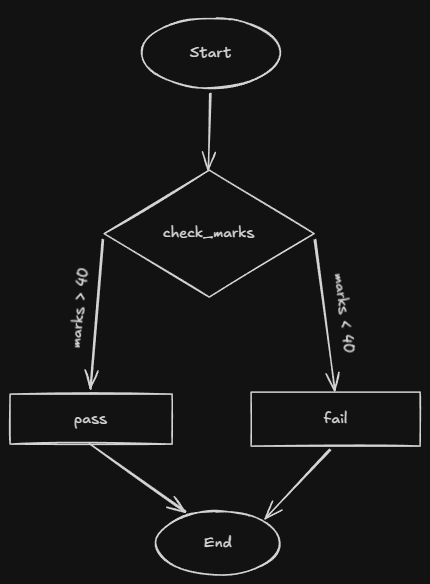

In [68]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [69]:
class AgentState(TypedDict):
    marks: int
    remark: str

In [ ]:
def passs(state: AgentState) -> AgentState:
    """This node checks if the candidate scored above 40 marks"""

    if state['marks'] >= 40:
        state['remark'] = 'Pass'
        return state

def fail(state: AgentState) -> AgentState:
    """This node checks if the candidate scored below 40 marks"""

    if state['marks'] < 40:
        state['remark'] = 'Fail'
        return state

def check_marks(state: AgentState) -> AgentState:
    """This node checks if the candidate passed or failed"""

    if state['marks '] >= 40:
        return "passed"
    else:
        return "failed"

In [71]:
graph = StateGraph(AgentState)

graph.add_node("passs", passs)
graph.add_node("fail", fail)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges (
    "router",
    check_marks,
    {
        "passed" : "passs",
        "failed" : "fail"
    }
)

graph.add_edge("passs", END)
graph.add_edge("fail", END)

app = graph.compile()

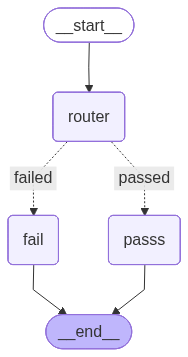

In [72]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [73]:
result = app.invoke({"marks": 45})
print(result['remark'])  # Output: Pass

Pass
